In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.preprocessing
import matplotlib.pyplot as plt
%matplotlib inline


In [30]:
df=pd.read_excel('Maths_1st_year_topics.xlsx')

In [31]:
df.head()

,Year,Exercise_id,Exercise,Appeared,Chapter_Name
0,2025,1,1.1,1,Complex Number
1,2025,2,1.2,1,Complex Number
2,2025,3,1.3,1,Complex Number
3,2025,4,2.1,1,Matrices
4,2025,5,2.2,1,Matrices


In [32]:
df['Chapter_Name'].unique()

array(['Complex Number', 'Matrices', 'Vectors', 'Sequences and Series',
       'Miscellaneous Series', 'Permutation, Combination and Probability',
       'Mathematical Induction and Binomial series',
       'Function and Graphs', 'Linear Programming',
       'Trigonometric Identities of sum and differences of angles',
       'Application of Trigonometry',
       'Graph of Trigonometry and Inverse Trigonometry Functions and Solutions of Trigonometric Equations'],
      dtype=object)

In [33]:
df.isnull().sum()

Year            0
Exercise_id     0
Exercise        0
Appeared        0
Chapter_Name    0
dtype: int64

In [34]:
chapter_weight_map = {
    'Complex Number':                                                    0.06,
    'Matrices':                                                          0.15,
    'Vectors':                                                           0.10,
    'Sequences and Series':                                              0.06,
    'Miscellaneous Series':                                              0.03,
    'Permutation, Combination and Probability':                          0.08,
    'Mathematical Induction and Binomial series':                        0.08,
    'Function and Graphs':                                               0.09,
    'Linear Programming':                                                0.05,
    'Trigonometric Identities of sum and differences of angles':         0.08,
    'Application of Trigonometry':                                       0.07,
    'Graph of Trigonometry and Inverse Trigonometry Functions and Solutions of Trigonometric Equations': 0.15,
}

In [35]:
df['chapter_weight'] = df['Chapter_Name'].map(chapter_weight_map)

In [36]:
df = df.sort_values(['Exercise', 'Year']).reset_index(drop=True)

In [37]:
gaps = []
last_year_since_appeared = {}
for _, row in df.iterrows():
    exercise = row['Exercise']
    year = int(row['Year'])
    appeared = row['Appeared']
    if exercise not in last_year_since_appeared:
        gaps.append(-1)
    else:
        gaps.append(year - last_year_since_appeared[exercise])
    if appeared == 1:
        last_year_since_appeared[exercise] = year
df['Gaps'] = gaps

In [38]:
years_in_data = df['Year'].unique()

frequency = []

for _, row in df.iterrows():
    exercise = row['Exercise']
    year = row['Year']
    
    prev_years = [y for y in years_in_data if y < year]
    last_5_years = prev_years[-5:]
    
    exercise_data = df[df['Exercise'] == exercise]
    count = exercise_data[exercise_data['Year'].isin(last_5_years)]['Appeared'].sum()
    
    frequency.append(int(count))

df['Frequency_Last_5'] = frequency

In [39]:
df['Appeared_last_year'] = df.groupby('Exercise')['Appeared'].shift(1).fillna(0).astype(int)

In [40]:
df['rolling_3'] = (df.groupby('Exercise')['Appeared']
                   .transform(lambda x: x.shift(1).rolling(3).sum())
                   .fillna(0))

In [41]:
df.isnull().sum()

Year                  0
Exercise_id           0
Exercise              0
Appeared              0
Chapter_Name          0
chapter_weight        0
Gaps                  0
Frequency_Last_5      0
Appeared_last_year    0
rolling_3             0
dtype: int64

In [42]:
df_model=df.copy()

In [43]:
train = df_model[df_model['Year'] < 2025]
test  = df_model[df_model['Year'] == 2025]

features = ['Gaps', 'Frequency_Last_5','Appeared_last_year','rolling_3','chapter_weight']
targets = 'Appeared'

X_train = train[features]
y_train = train[targets]

X_test = test[features]
y_test = test[targets]

In [44]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [45]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

In [46]:
from sklearn.metrics import accuracy_score,precision_score,recall_score
y_prob_lr = pipe.predict_proba(X_test)[:, 1]
accuracy_lr = accuracy_score(y_test, y_pred)
precision_lr = precision_score(y_test, y_pred)
recall_lr = recall_score(y_test, y_pred)
print(f"Accuracy:  {accuracy_lr * 100:.2f}%")
print(f'Precision:{precision_lr*100:.2f}%')
print(f'Recall:{recall_lr*100:.2f}%')

Accuracy:  72.92%
Precision:67.57%
Recall:96.15%


In [47]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
print(f"Dummy Accuracy: {accuracy_score(y_test, dummy.predict(X_test)):.4f}")

Dummy Accuracy: 0.5417


In [48]:
from sklearn.metrics import classification_report

y_prob_lr = pipe.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.3, 0.25]:
    y_pred_thresh = (y_prob_lr >= threshold).astype(int)
    print(f'Accuracy:{accuracy_score(y_test,y_pred_thresh)*100:.2f}%')
    print(f"\nThreshold={threshold}")
    print(classification_report(y_test, y_pred_thresh))

Accuracy:72.92%

Threshold=0.5
              precision    recall  f1-score   support

           0       0.91      0.45      0.61        22
           1       0.68      0.96      0.79        26

    accuracy                           0.73        48
   macro avg       0.79      0.71      0.70        48
weighted avg       0.78      0.73      0.71        48

Accuracy:68.75%

Threshold=0.4
              precision    recall  f1-score   support

           0       1.00      0.32      0.48        22
           1       0.63      1.00      0.78        26

    accuracy                           0.69        48
   macro avg       0.82      0.66      0.63        48
weighted avg       0.80      0.69      0.64        48

Accuracy:62.50%

Threshold=0.3
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        22
           1       0.59      1.00      0.74        26

    accuracy                           0.62        48
   macro avg       0.80      0.59  

c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\aliah\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Step 1 - Full data pe train karo
features = ['Gaps', 'Frequency_Last_5', 'Appeared_last_year', 'rolling_3', 'chapter_weight']
targets = 'Appeared'

X_full = df_model[features].copy()
y_full = df_model[targets]

pipe_full = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
])
pipe_full.fit(X_full, y_full)

# Step 2 - 2026 ka base
df_2026 = df[df['Year'] == 2025][['Exercise_id', 'Exercise', 'Chapter_Name', 'Appeared', 'Gaps',
              'Frequency_Last_5', 'Appeared_last_year',
              'rolling_3', 'chapter_weight']].copy()
df_2026['Year'] = 2026

# Step 3 - Features update
df_2026['Appeared_last_year'] = df_2026['Appeared']
df_2026['Gaps'] = df_2026.apply(
    lambda row: 1 if row['Appeared'] == 1 else row['Gaps'] + 1, axis=1)
df_2026['Frequency_Last_5'] = df_2026.apply(
    lambda row: min(5, row['Frequency_Last_5'] + row['Appeared']), axis=1)
df_2026['rolling_3'] = df_2026.apply(
    lambda row: min(3, row['rolling_3'] + row['Appeared']), axis=1)

# Step 4 - Predict
X_2026 = df_2026[features].copy()
prob_2026 = pipe_full.predict_proba(X_2026)[:, 1]
df_2026['Probability'] = prob_2026

# Step 5 - Filter + Category
result_2026 = df_2026[['Exercise_id', 'Exercise', 'Chapter_Name', 'Probability']]\
              .sort_values('Probability', ascending=False)\
              .reset_index(drop=True)

final_predictions = result_2026[result_2026['Probability'] >= 0.5].head(25).copy()

final_predictions['Category'] = final_predictions['Probability'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

# Step 6 - Years appeared nikalo
appeared_years_list = []
for _, row in final_predictions.iterrows():
    topic = row['Exercise']
    years = df[
        (df['Exercise'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_predictions['Years_Appeared'] = appeared_years_list
final_predictions['Total_Appearances'] = final_predictions['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)

# Step 7 - Save
final_predictions.to_excel('Maths_1stYear_Predictions_2026.xlsx', index=False)
print(final_predictions)

    Exercise_id  Exercise                                       Chapter_Name  \
0             2       1.2                                     Complex Number   
1             3       1.3                                     Complex Number   
2            16       4.4                               Sequences and Series   
3            42      11.4                        Application of Trigonometry   
4            30       7.3         Mathematical Induction and Binomial series   
5            29       7.2         Mathematical Induction and Binomial series   
6            24       6.2           Permutation, Combination and Probability   
7            38      10.3  Trigonometric Identities of sum and difference...   
8            31       8.1                                Function and Graphs   
9            12       3.5                                            Vectors   
10           10       3.3                                            Vectors   
11            9       3.2               

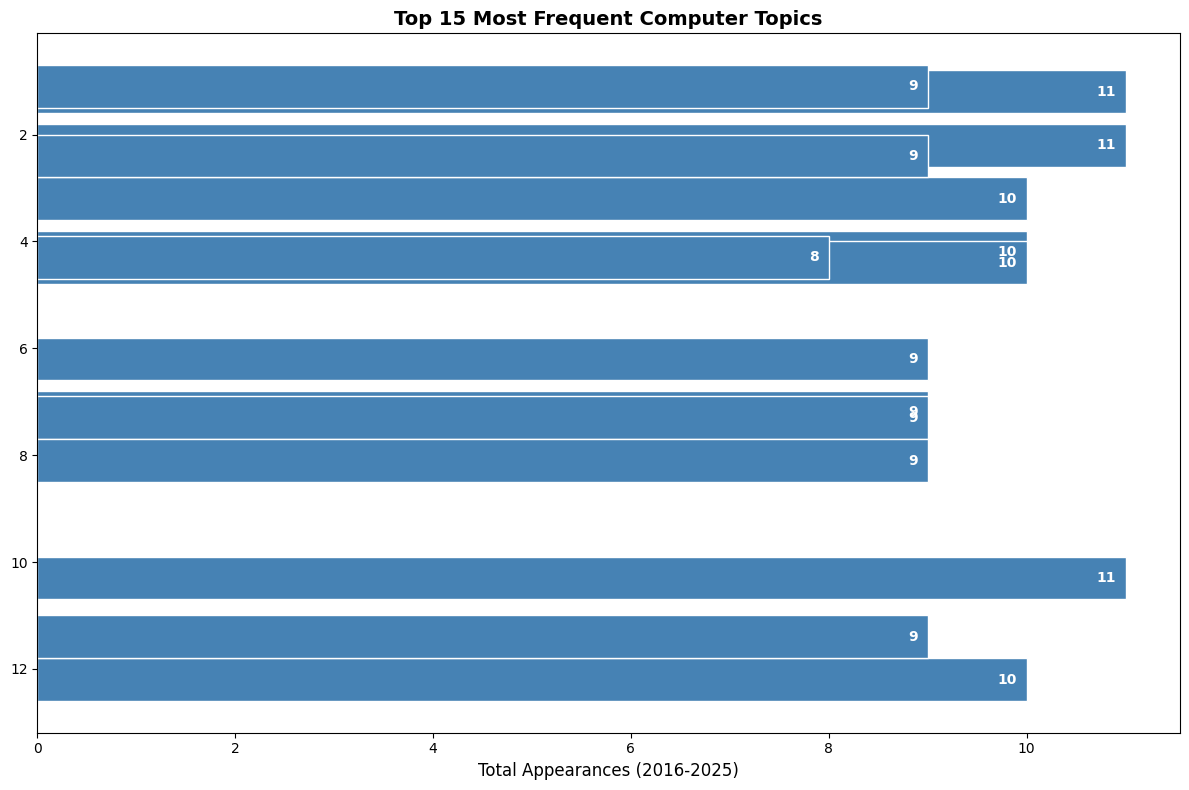

In [50]:
import matplotlib.pyplot as plt

topic_freq = df.groupby('Exercise')['Appeared'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(topic_freq.index, topic_freq.values, color='steelblue', edgecolor='white')
plt.xlabel('Total Appearances (2016-2025)', fontsize=12)
plt.title('Top 15 Most Frequent Computer Topics', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Values bar ke andar dikhao
for bar, val in zip(bars, topic_freq.values):
    plt.text(val - 0.1, bar.get_y() + bar.get_height()/2, 
             str(int(val)), va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph1_frequency.png', dpi=150)
plt.show()

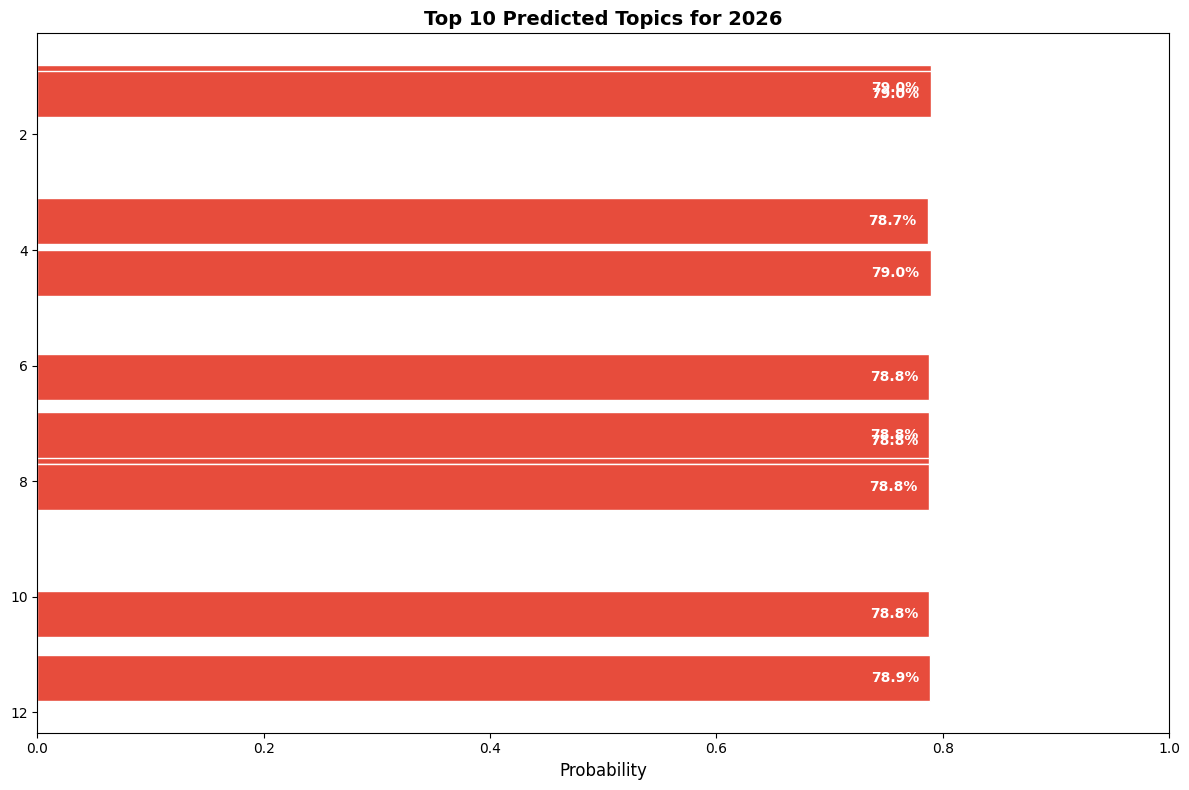

In [51]:
top10 = result_2026.head(10)

plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if p >= 0.85 else '#f39c12' if p >= 0.80 else '#e74c3c' 
          for p in top10['Probability']]
bars = plt.barh(top10['Exercise'], top10['Probability'], color=colors, edgecolor='white')
plt.xlabel('Probability', fontsize=12)
plt.title('Top 10 Predicted Topics for 2026', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Probability']):
    plt.text(val - 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.1%}', va='center', ha='right', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('graph2_predictions.png', dpi=150)
plt.show()